In [ ]:
import os
    
import sys
import numpy as np

import torch
import zuko
    
from geobed.utils.sample_distribution import SampleDistribution
from geobed import BED_base_explicit, BED_base_nuisance

if 'PATH_SET' not in locals():
    os.chdir('..')
    PATH_SET = True
    os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

    os.environ['OMP_NUM_THREADS'] = '1'
    os.environ['MKL_NUM_THREADS'] = '1'

    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)

from helpers.geographic_setup import (design_space_full, topo_data)

from helpers.helper_functions import concave_hull2D_prior_dist_constructor

from helpers.likelihood import (
    DataLikelihoodArrival,
    DataLikelihoodAttenuationArrival)

from helpers.forward import TTLookup

from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle.mplstyle')


PLOT_SETUP = False
n_workers = 1  # or lower, depending on the task

In [ ]:
design_space = design_space_full

model_prior_samples = torch.load('data/priors/prior_samples_full_disp.pt')
model_prior_sample_dist = SampleDistribution(
    model_prior_samples)

forward_function = TTLookup(
    model_prior_samples, design_space_full,
    torch.load('data/data_lookup/gradient_full_disp.pt'),)

data_likelihood = DataLikelihoodArrival(
                forward_function=forward_function,
                dependence_distance=100.0,
                vel_sigma=0.05,
                tt_obs_std=0.01,
            )

BED_class = BED_base_explicit(
    data_likelihood_func=data_likelihood,
    m_prior_dist=model_prior_sample_dist,
)

In [3]:
def fitness_function(ga_instance, solution, solution_idx):
    if solution.ndim == 1:
        design = design_space[list(solution)].unsqueeze(0)
    elif solution.ndim == 2:
        design = torch.stack([design_space[sol] for sol in solution])

    eig = BED_class.calculate_EIG(
        design,
        eig_method='NMC',        
        eig_method_kwargs=dict(N = 500, reuse_M = True),
        num_workers=1,
        random_seed=0,
        progress_bar=False,
    )[0]
    
    if solution.ndim == 1:
        return eig.item()
    else:
        return eig.numpy()


In [4]:
from shapely.geometry import MultiPoint
import shapely

# covert design space to shapely geometry
design_space_full_shapely = MultiPoint(
    [design_space[i, :2] for i in range(len(design_space))])

# # get concave hull
concave_hull_full = shapely.concave_hull(design_space_full_shapely, ratio=0.01)
# convert to torch tensor
concave_hull_full = torch.tensor(concave_hull_full.exterior.coords[:-1])
# find right indices and add third and fourth dimension again
indices = [torch.where(
    torch.all(design_space_full[:, :2] == concave_hull_full[i], dim=1))[0] for i in range(len(concave_hull_full))]

concave_hull_full = design_space_full[indices]

In [5]:
import pygad
from tqdm.auto import tqdm

N_rec = 10

# N_pop = max(N_rec*2, 10)
N_pop = 10

N_generations = 2000
N_design_space = design_space.shape[0]

def on_generation(ga):
    if not hasattr(on_generation, "pbar"):
        on_generation.pbar = tqdm(total=N_generations, desc="Generations")
        on_generation.best_fitness = -float('inf')
    
    current_best = ga.best_solution()[1]
    if current_best > on_generation.best_fitness:
        on_generation.best_fitness = current_best
        on_generation.pbar.set_postfix({'Best EIG': f'{current_best:.3f}'})
    
    on_generation.pbar.update(1)
    
    if ga.generations_completed == N_generations:
        on_generation.pbar.close()

design_space_dist = concave_hull2D_prior_dist_constructor(
        design_space[..., :3], topo_data,
        base_dist='sobol',
        buffer=100, depth=0, ratio=0.05,
        # high buffer to bias towards sides
    )

torch.manual_seed(0)
random_design_list = torch.stack([
    design_space_dist.sample(N_rec) for _ in range(N_pop)
]).float()  
# for each design in the list, find closest design in design_space
initial_population = torch.cdist(
    random_design_list, design_space[..., :3]).argmin(dim=-1).tolist()


ga = pygad.GA(
    num_generations=N_generations,
    num_parents_mating=N_pop//2,
    fitness_func=fitness_function,
    sol_per_pop=N_pop,
    num_genes=N_rec,
    keep_elitism=2,
    initial_population=initial_population,
    gene_type=int,
    gene_space={'low': 0, 'high': N_design_space-1},
    allow_duplicate_genes=False,
    random_mutation_min_val=0,
    random_mutation_max_val=N_design_space-1,
    mutation_type="adaptive",
    mutation_probability=(0.5, 0.1),
    # stop_criteria=f'saturate_{N_generations//10}',
    on_generation=on_generation,
    random_seed=0,
    save_solutions=True, # mostly to allow caching
)

ga.run()

/home/dstrutz/miniforge3/envs/cdv_oed_benchmark/lib/python3.13/site-packages/pygad/pygad.py:1145: UserWarning: Use the 'save_solutions' parameter with caution as it may cause memory overflow when either the number of generations, number of genes, or number of solutions in population is large.
  warnings.warn("Use the 'save_solutions' parameter with caution as it may cause memory overflow when either the number of generations, number of genes, or number of solutions in population is large.")


Generations:   0%|          | 0/2000 [00:00<?, ?it/s]

In [6]:
fitness = np.array(ga.best_solutions_fitness)
best_design_idx = ga.best_solution()[0]
best_design = design_space[best_design_idx]

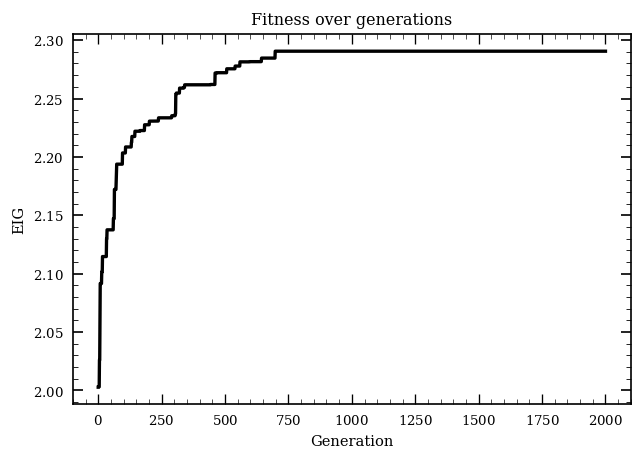

In [7]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)

ax.plot(fitness, color="black", linewidth=2)

ax.set_xlabel("Generation")
ax.set_ylabel("EIG")

ax.set_title("Fitness over generations")

plt.show()

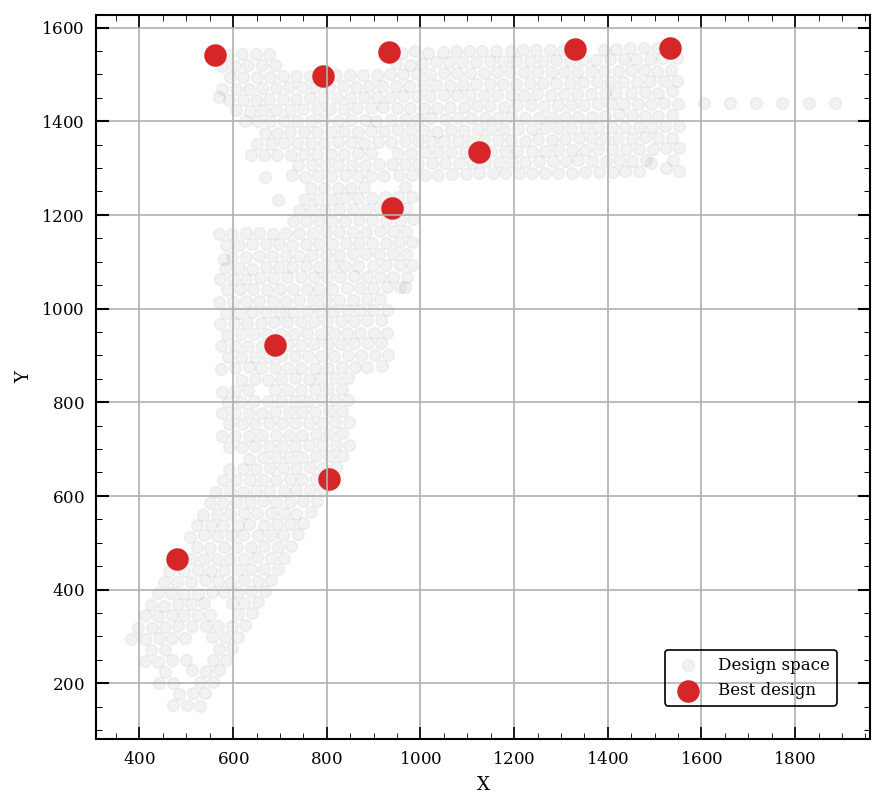

In [8]:
# Get all designs from hall of fame
fig, ax = plt.subplots(figsize=(6, 6))

# Plot full design space
ax.scatter(design_space[:, 0], design_space[:, 1], c='gray', alpha=0.1, label='Design space')
# Plot best design 
scatter = ax.scatter(
    best_design[:, 0], best_design[:, 1],
    c='tab:red', s=100, alpha=1.0,
    label='Best design')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')
ax.legend()
ax.grid(True)

plt.tight_layout()